# Module 7 - Session 1: Practical Exercises

**Total Time Estimate:** 90-120 minutes

**Objective:** To implement the Epsilon-Greedy algorithm from scratch to solve a simple Multi-Armed Bandit problem, and to analyze the impact of exploration.

## Setup

Please use Python with `numpy` and `matplotlib`.

```bash
pip install numpy matplotlib
```


## Exercise 1: Conceptual Questions (30 minutes)

### Foundation

Reinforcement learning problems are defined by interaction: an agent takes actions in an environment, receives rewards, and gradually learns which actions are best.

### Build

1. **Categorize the Problem**

**a) Mouse in a maze**
- **Agent:** The mouse
- **Environment:** The maze
- **State:** The mouse's current position in the maze
- **Actions:** Move up, down, left, or right
- **Reward:** A positive reward for reaching the cheese, and possibly a small negative reward for each step to encourage shorter paths

**b) AI trading stocks**
- **Agent:** The trading AI
- **Environment:** The stock market
- **State:** Current prices, recent trends, portfolio balance, and owned assets
- **Actions:** Buy, sell, or hold
- **Reward:** Profit or loss after each decision or over a trading period

**c) Thermostat controlling a room**
- **Agent:** The thermostat controller
- **Environment:** The room and its surrounding conditions
- **State:** Current room temperature, target temperature, and possibly outdoor temperature
- **Actions:** Increase heating, decrease heating, keep temperature unchanged, or turn cooling on/off
- **Reward:** Higher reward for staying near the target comfort range while using less energy

2. **The Epsilon Value**

If `epsilon = 0`, the agent always exploits and never explores. It keeps choosing the arm with the highest current estimated reward, even if that estimate was based on very limited experience. If `epsilon = 1`, the agent always explores and picks actions completely at random, so it never consistently uses what it has learned. The problem with both extremes is that one prevents discovery of better options, while the other prevents stable improvement.

3. **Reward Shaping**

Reward shaping can speed up learning because it gives feedback before the final goal is reached. Instead of waiting for one delayed reward at the very end, the learner receives smaller signals that indicate it is moving in the right direction. That reduces ambiguity, helps useful behaviors appear sooner, and makes the full task easier to learn.

### Result

A good reinforcement learning setup depends on defining meaningful states, actions, and rewards. Epsilon controls the balance between trying new actions and using known good ones, while reward shaping can make difficult tasks learnable much faster.


## Exercise 2: Implementing a Multi-Armed Bandit (60 minutes)

This exercise builds a simple 10-armed bandit and solves it with the Epsilon-Greedy algorithm.

Note: the original prompt suggests drawing win rates from `np.random.randn(k)`, but Bernoulli win rates must be probabilities between `0` and `1`. For that reason, this solution uses `np.random.rand(k)`.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


class Bandit:
    def __init__(self, k=10):
        self.k = k
        self.win_rates = np.random.rand(k)

    def pull(self, arm_index):
        return 1 if np.random.rand() < self.win_rates[arm_index] else 0


In [10]:
def epsilon_greedy(bandit, epsilon, num_plays):
    counts = np.zeros(bandit.k, dtype=int)
    values = np.zeros(bandit.k, dtype=float)
    average_rewards = []
    total_reward = 0

    for step in range(num_plays):
        if np.random.rand() < epsilon:
            arm_index = np.random.randint(bandit.k)
        else:
            arm_index = np.argmax(values)

        reward = bandit.pull(arm_index)

        counts[arm_index] += 1
        values[arm_index] = values[arm_index] + (1 / counts[arm_index]) * (reward - values[arm_index])

        total_reward += reward
        average_rewards.append(total_reward / (step + 1))

    return counts, values, average_rewards


In [11]:
bandit = Bandit(k=10)
counts, learned_values, average_rewards = epsilon_greedy(bandit, epsilon=0.1, num_plays=1000)

print("True win rates:")
print(np.round(bandit.win_rates, 3))
print()
print("Estimated values:")
print(np.round(learned_values, 3))
print()
print("Pull counts:")
print(counts)
print()

best_true_arm = np.argmax(bandit.win_rates)
best_learned_arm = np.argmax(learned_values)

print("Best true arm:", best_true_arm)
print("Best learned arm:", best_learned_arm)
print("Best true win rate:", round(bandit.win_rates[best_true_arm], 3))
print("Estimated value of learned best arm:", round(learned_values[best_learned_arm], 3))


True win rates:
[0.375 0.951 0.732 0.599 0.156 0.156 0.058 0.866 0.601 0.708]

Estimated values:
[0.462 0.945 0.923 0.636 0.143 0.091 0.125 0.895 0.5   0.692]

Pull counts:
[ 13 874  13  11   7  11   8  38  12  13]

Best true arm: 1
Best learned arm: 1
Best true win rate: 0.951
Estimated value of learned best arm: 0.945


### Observation (Markdown Answer)

### Foundation

The goal is not to estimate every arm perfectly. The real goal is to identify and exploit the best arm often enough to maximize long-term reward.

### Build

After 1000 plays with `epsilon = 0.1`, the learned estimates should usually be reasonably close to the true win rates for the most frequently explored arms. In many runs, the agent identifies the correct best arm or at least a near-optimal one. Small differences are expected because the rewards are stochastic, so the observed averages will not match the true probabilities exactly.

### Result

Epsilon-Greedy works because a small amount of exploration helps the agent discover strong arms, while repeated exploitation lets it accumulate reward efficiently.


## Exercise 3: Challenge Problem - The Impact of Epsilon (30 minutes)

This part compares three epsilon values on the same underlying bandit so the difference comes only from the exploration strategy.


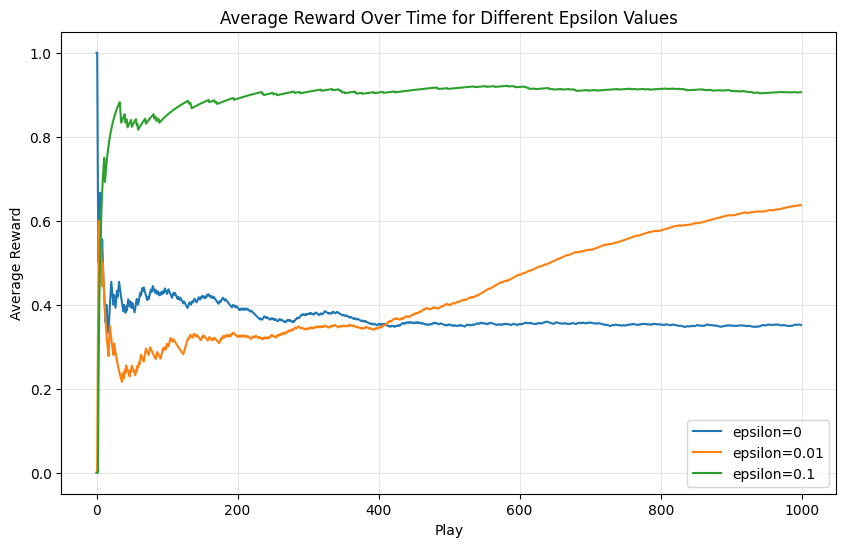

In [12]:
np.random.seed(42)

base_bandit = Bandit(k=10)
shared_win_rates = base_bandit.win_rates.copy()

epsilon_values = [0, 0.01, 0.1]
results = {}

for epsilon in epsilon_values:
    test_bandit = Bandit(k=10)
    test_bandit.win_rates = shared_win_rates.copy()
    _, _, avg_rewards = epsilon_greedy(test_bandit, epsilon=epsilon, num_plays=1000)
    results[epsilon] = avg_rewards

plt.figure(figsize=(10, 6))
for epsilon, avg_rewards in results.items():
    plt.plot(avg_rewards, label=f"epsilon={epsilon}")

plt.xlabel("Play")
plt.ylabel("Average Reward")
plt.title("Average Reward Over Time for Different Epsilon Values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Analysis (Markdown Answer)

### Foundation

The plot visualizes the exploration-exploitation trade-off directly.

### Build

At the beginning, `epsilon = 0` can sometimes look strong because it quickly commits to whichever arm gives an early reward. However, that early success is risky because the agent may lock onto a suboptimal arm and never test better ones. `epsilon = 0.1` usually performs better in the long run because it keeps exploring enough to discover the best arm while still exploiting it often. `epsilon = 0.01` is a middle ground: it explores a little, but sometimes not enough to correct early mistakes as reliably as `epsilon = 0.1`.

### Result

Pure greed may look efficient early, but moderate exploration usually wins over time. That is the core idea of Epsilon-Greedy: a small amount of exploration improves long-term learning.
